In [8]:
import glob
import numpy as np

# Load all npy files that start with "threaded_npp"
npy_files = glob.glob("threaded_npp*.npy")
print(f"Found {len(npy_files)} npy files.")

files = []
for file in npy_files:
    print(f"  {file}")
    data = np.load(file, allow_pickle=True).item()
    files.append(data)
print(files)

print(files[0].keys())

Found 3 npy files.
  threaded_npp_benchmark_results_1764919995.6938665.npy
  threaded_npp_benchmark_results_1764920080.7463527.npy
  threaded_npp_benchmark_results_1764921340.7026784_size50.npy
[{'final_spins': array([ 1,  1, -1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1, -1, -1, -1, -1,
       -1, -1,  1, -1,  1, -1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1, -1,
       -1, -1,  1, -1,  1,  1]), 'min_energy': 1.9389010989010989, 'trace': [2.855970695970696, 2.6536996336996337, 2.4079120879120874, 2.523956043956044, 2.5247619047619043, 2.6754578754578753, 2.4506227106227105, 2.6496703296703297, 2.8148717948717947, 2.6609523809523807, 2.908351648351648, 2.9438095238095237, 2.9663736263736262, 2.776996336996337, 2.6762637362637363, 2.822124542124542, 2.681904761904762, 2.7246153846153844, 2.7165567765567764, 2.7383150183150184, 2.335384615384615, 2.78021978021978, 2.6956043956043954, 2.709304029304029, 2.556996336996337, 2.7939194139194137, 2.59003663003663, 2.8898168498168495, 2.3498901098901

C:\Users\harsh\AppData\Local\Temp\ipykernel_14556\3478395061.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


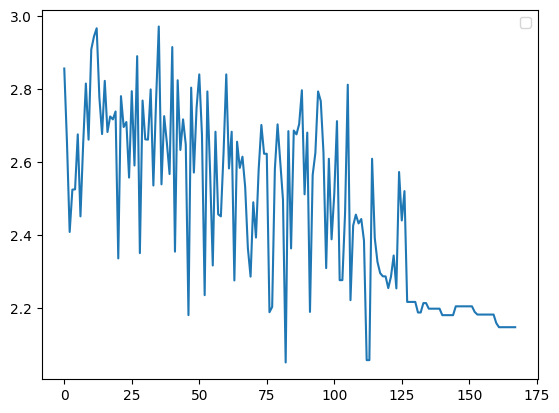

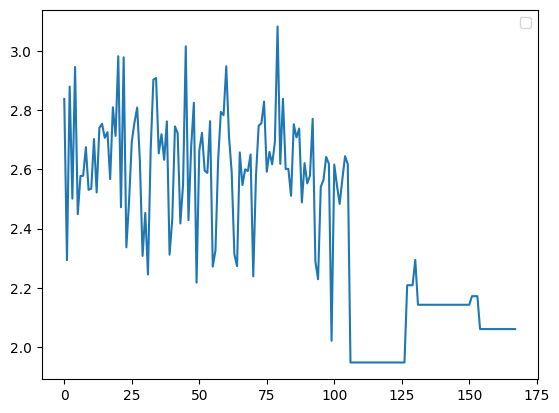

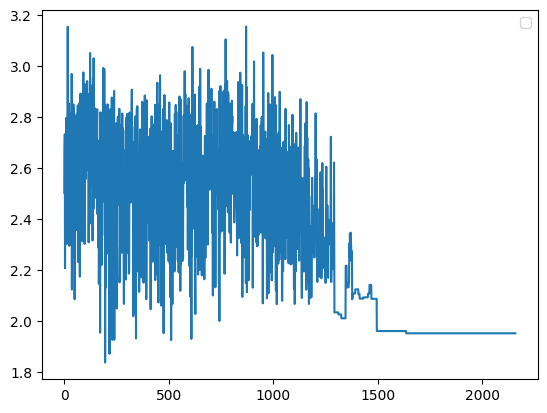

In [12]:
import matplotlib.pyplot as plt

for file in files:
    for key in file:
        if key == "trace":
            plt.plot(file[key])
            plt.legend()
            plt.show()  


In [15]:
import serial
import time

# Configure serial connection to com21
ser = serial.Serial('COM21', baudrate=9600, timeout=1)

# Set duration to collect data (in seconds)
duration = 10

# Collect data
start_time = time.time()
collected_data = []

print(f"Collecting data from COM21 for {duration} seconds...")

while time.time() - start_time < duration:
    if ser.in_waiting > 0:
        line = ser.readline()
        collected_data.append(line)
        print(line)

ser.close()
print(f"Collected {len(collected_data)} data points")

KeyboardInterrupt: 

In [ ]:
import serial
import serial.tools.list_ports
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from collections import deque
import threading
import time

# ------------------------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------------------------
# Set this to your specific COM port (e.g., 'COM3' on Windows, '/dev/ttyACM0' on Linux)
# If set to None, the script will try to auto-detect the Tiva Board.
SERIAL_PORT = None 
BAUD_RATE = 115200
MAX_POINTS = 200  # How many data points to show on the graph at once

# ------------------------------------------------------------------------------
# GLOBALS
# ------------------------------------------------------------------------------
data_buffer = deque([0.0] * MAX_POINTS, maxlen=MAX_POINTS)
stop_event = threading.Event()

def find_tiva_port():
    """Attempts to auto-detect the Tiva C Launchpad port."""
    ports = list(serial.tools.list_ports.comports())
    for p in ports:
        # Tiva boards often show up as "Stellaris" or "Tiva"
        if "Stellaris" in p.description or "Tiva" in p.description:
            return p.device
    
    # Fallback: Return the first available port if specific one not found
    if len(ports) > 0:
        return ports[0].device
    return None

def serial_reader(port_name):
    """
    Background thread to read data continuously from UART.
    Protocol: [0xA5] [Low Byte] [High Byte]
    """
    try:
        ser = serial.Serial(port_name, BAUD_RATE, timeout=1)
        print(f"Connected to {port_name} at {BAUD_RATE} baud.")
        ser.reset_input_buffer()
        
        while not stop_event.is_set():
            # 1. Read one byte to check for Sync Header (0xA5)
            # We use read(1) which blocks until a byte comes or timeout
            if ser.in_waiting > 0:
                header = ser.read(1)
                
                if header == b'\xA5':
                    # 2. We found the header, now read the next 2 bytes (Low, High)
                    # We wait slightly to ensure bytes are available or use blocking read
                    data_bytes = ser.read(2)
                    
                    if len(data_bytes) == 2:
                        low_byte = data_bytes[0]
                        high_byte = data_bytes[1]
                        
                        # Reconstruct 12-bit ADC value
                        adc_raw = low_byte | (high_byte << 8)
                        
                        # Convert to Voltage (0 - 4095 -> 0V - 3.3V)
                        voltage = (adc_raw / 4095.0) * 3.3
                        
                        # Add to buffer (thread-safe deque)
                        data_buffer.append(voltage)
    except serial.SerialException as e:
        print(f"Serial Error: {e}")
    except Exception as e:
        print(f"Error: {e}")
    finally:
        if 'ser' in locals() and ser.is_open:
            ser.close()
            print("Serial connection closed.")

def update_plot(frame, line):
    """Called by Matplotlib animation to update the graph."""
    line.set_ydata(data_buffer)
    return line,

def main():
    # 1. Detect Port
    target_port = "COM21"
    if target_port is None:
        target_port = find_tiva_port()
    
    if target_port is None:
        print("Error: No serial ports found. Connect the Tiva board.")
        return

    # 2. Start Serial Thread
    # We use a thread so reading doesn't block the plotting GUI
    thread = threading.Thread(target_port="COM21", args=(target_port,), daemon=True)
    thread.start()

    # 3. Setup Plot
    fig, ax = plt.subplots()
    ax.set_title(f"Real-Time Voltage (ADC) - {target_port}")
    ax.set_ylabel("Voltage (V)")
    ax.set_ylim(-0.1, 3.5) # Set Y-axis limits (0 to 3.3V with padding)
    
    # Create x-axis indices
    x_data = range(MAX_POINTS)
    line, = ax.plot(x_data, data_buffer, 'b-', lw=2)

    # Hide X-axis labels (optional, since it's a rolling stream)
    ax.set_xticklabels([])
    ax.set_xlabel("Time (Samples)")

    # 4. Start Animation
    # interval=20 means update every 20ms (50 FPS)
    ani = animation.FuncAnimation(fig, update_plot, fargs=(line,), interval=20, blit=True)

    print("Plotting started... Close window to exit.")
    plt.show()

    # 5. Cleanup when window closes
    stop_event.set()
    thread.join(timeout=1.0)

if __name__ == "__main__":
    main()

TypeError: Thread.__init__() got an unexpected keyword argument 'target_port'